# Tabular Baselines Evaluation

В этом ноутбуке анализируются результаты табличных baseline-моделей для HDFS anomaly detection.

Важно: это **full-block baseline**. Модели используют признаки, агрегированные по всему `block_id`: счетчики событий, длину последовательности, latency и агрегаты `TimeInterval`. Такой подход полезен как проверка наличия сигнала в данных, но он не полностью соответствует production-like сценарию, где события приходят последовательно.

Эксперимент разделен на два шага:

1. `scripts/train_tabular_baseline.py` обучает модели и сохраняет raw anomaly scores на validation/test.
2. `scripts/evaluate_tabular_baselines.py` подбирает threshold на validation по максимуму F1 и применяет его к test.

Threshold не подбирается на test set.

## 1 Импорты и пути

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "reports" / "tabular_baselines").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find reports/tabular_baselines from current working directory"
    )


ROOT = find_project_root()
REPORT_DIR = ROOT / "reports" / "tabular_baselines"
TABLE_DIR = REPORT_DIR / "tables"
FIG_DIR = REPORT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True, parents=True)

print("Project root:", ROOT)
print("Report root:", REPORT_DIR)
print("Tables:", TABLE_DIR)

Project root: /Users/andrew/PycharmProjects/hdfs-log-anomaly-detection
Reports: /Users/andrew/PycharmProjects/hdfs-log-anomaly-detection/reports/tabular_baselines


## 2 Загрузка результатов

In [3]:
validation_metrics = pd.read_csv(TABLE_DIR / "tabular_validation_metrics.csv")
test_metrics = pd.read_csv(TABLE_DIR / "tabular_test_metrics.csv")
thresholds = pd.read_csv(TABLE_DIR / "tabular_thresholds.csv")

print("Validation metrics")
display(validation_metrics.round(4))

print("Test metrics")
display(test_metrics.round(4))

print("Thresholds")
display(thresholds.round(4))

Validation metrics


,model,threshold,f1,precision,recall,fpr,average_precision,tn,fp,fn,tp
0,logistic_regression,0.9535,0.9893,0.9810,0.9978,0.0006,0.9932,89264,52,6,2688
1,isolation_forest,0.5596,0.3306,0.2497,0.4892,0.0443,0.1544,85355,3961,1376,1318
2,random_forest,0.3967,0.9978,0.9959,0.9996,0.0001,0.9999,89305,11,1,2693


Test metrics


,model,threshold,f1,precision,recall,fpr,average_precision,tn,fp,fn,tp
0,logistic_regression,0.9535,0.9912,0.9839,0.9985,0.0005,0.9930,111590,55,5,3363
1,isolation_forest,0.5596,0.3279,0.2474,0.4857,0.0446,0.1547,106669,4976,1732,1636
2,random_forest,0.3967,0.9988,0.9985,0.9991,0.0000,1.0000,111640,5,3,3365


Thresholds


,model,strategy,threshold,validation_best_f1
0,logistic_regression,max_f1,0.9535,0.9893
1,isolation_forest,max_f1,0.5596,0.3306
2,random_forest,max_f1,0.3967,0.9978


**Промежуточный вывод.** На test split лучше всего выглядит Random Forest (`F1 ≈ 0.999`, `FP = 5`, `FN = 3`). Logistic Regression почти не уступает (`F1 ≈ 0.991`). Isolation Forest заметно слабее: низкий `F1 ≈ 0.328`, много ложных срабатываний (`FP = 4976`) и пропущенных аномалий (`FN = 1732`).

## 3 Сравнение моделей на test

Основной критерий для табличных baseline - F1. Дополнительно смотрим precision/recall, FPR и average precision.

- `F1` основная метрика качеста, так как присутствует дисбаланс классов
- `FPR` показывает долю нормальных блоков, ошибочно помеченных как anomaly
- `average_precision` показывает качество ранжирования anomaly score без выбора конкретного threshold

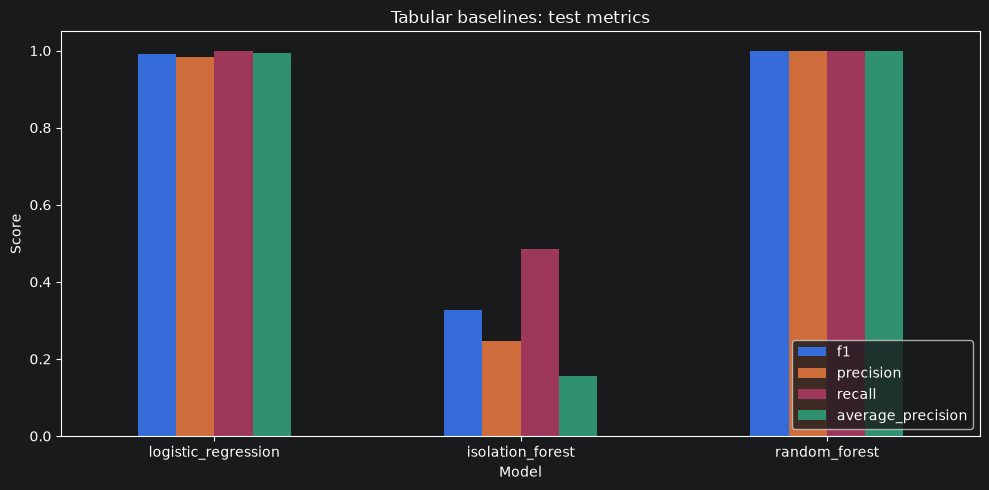

In [4]:
plot_metrics = ["f1", "precision", "recall", "average_precision"]
plot_df = test_metrics.set_index("model")[plot_metrics]

ax = plot_df.plot(kind="bar", figsize=(10, 5), ylim=(0, 1.05))
ax.set_title("Tabular baselines: test metrics")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "tabular_test_metrics_bar.png", dpi=300)
plt.show()

**Промежуточный вывод.** Supervised-модели резко превосходят Isolation Forest по F1, precision, recall и average precision. У Logistic Regression и Random Forest качество ранжирования почти идеальное, тогда как у Isolation Forest `average_precision ≈ 0.155`, то есть score плохо отделяет аномалии от нормальных блоков.

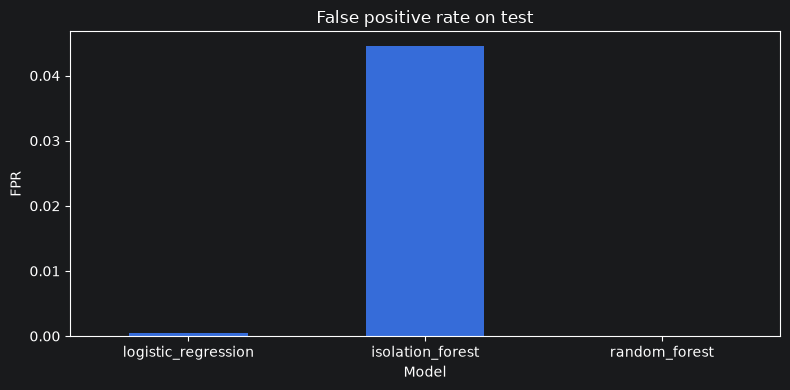

In [5]:
ax = test_metrics.set_index("model")["fpr"].plot(kind="bar", figsize=(8, 4))
ax.set_title("False positive rate on test")
ax.set_xlabel("Model")
ax.set_ylabel("FPR")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "tabular_test_fpr_bar.png", dpi=300)
plt.show()

**Промежуточный вывод.** По FPR разрыв особенно заметен: у Logistic Regression около `0.0005`, у Random Forest около `0.00004`, а у Isolation Forest около `0.0446`. Для anomaly detection это критично: высокий FPR означает много нормальных блоков, ошибочно отправленных в алерты.

## 4 Confusion Matrices

Матрицы ошибок построены на test split при threshold, выбранном на validation split.

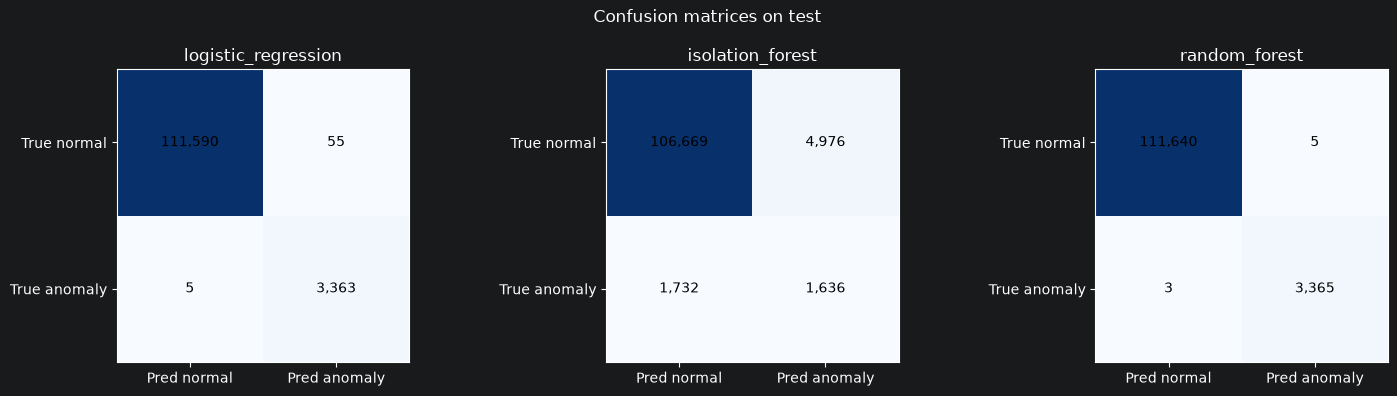

In [6]:
def confusion_matrix_from_row(row: pd.Series) -> np.ndarray:
    return np.array(
        [
            [row["tn"], row["fp"]],
            [row["fn"], row["tp"]],
        ],
        dtype=int,
    )


fig, axes = plt.subplots(1, len(test_metrics), figsize=(5 * len(test_metrics), 4))
if len(test_metrics) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, test_metrics.iterrows(), strict=True):
    matrix = confusion_matrix_from_row(row)
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_title(row["model"])
    ax.set_xticks([0, 1], labels=["Pred normal", "Pred anomaly"])
    ax.set_yticks([0, 1], labels=["True normal", "True anomaly"])

    for i in range(2):
        for j in range(2):
            value = matrix[i, j]
            ax.text(j, i, f"{value:,}", ha="center", va="center", color="black")

fig.suptitle("Confusion matrices on test")
fig.tight_layout()
plt.savefig(FIG_DIR / "tabular_confusion_matrices_test.png", dpi=300)
plt.show()

**Промежуточный вывод.** Confusion matrices подтверждают картину из метрик. Logistic Regression ошибается редко (`55 FP`, `5 FN`), Random Forest почти не ошибается (`5 FP`, `3 FN`), а Isolation Forest дает тысячи false positives и пропускает примерно половину аномалий.

## 5 Validation vs Test

Сравним validation и test, чтобы проверить, насколько стабильно переносится выбранный threshold.

In [7]:
comparison = validation_metrics[
    ["model", "f1", "precision", "recall", "fpr", "average_precision"]
].merge(
    test_metrics[["model", "f1", "precision", "recall", "fpr", "average_precision"]],
    on="model",
    suffixes=("_val", "_test"),
)

for metric in ["f1", "precision", "recall", "fpr", "average_precision"]:
    comparison[f"{metric}_diff_test_minus_val"] = (
        comparison[f"{metric}_test"] - comparison[f"{metric}_val"]
    )

display(comparison.round(4))

,model,f1_val,precision_val,recall_val,fpr_val,average_precision_val,f1_test,precision_test,recall_test,fpr_test,average_precision_test,f1_diff_test_minus_val,precision_diff_test_minus_val,recall_diff_test_minus_val,fpr_diff_test_minus_val,average_precision_diff_test_minus_val
0,logistic_regression,0.9893,0.9810,0.9978,0.0006,0.9932,0.9912,0.9839,0.9985,0.0005,0.9930,0.0018,0.0029,0.0007,-0.0001,-0.0002
1,isolation_forest,0.3306,0.2497,0.4892,0.0443,0.1544,0.3279,0.2474,0.4857,0.0446,0.1547,-0.0028,-0.0022,-0.0035,0.0002,0.0004
2,random_forest,0.9978,0.9959,0.9996,0.0001,0.9999,0.9988,0.9985,0.9991,0.0000,1.0000,0.0010,0.0026,-0.0005,-0.0001,0.0001


**Промежуточный вывод.** Validation и test близки по основным метрикам, значит выбранные thresholds переносятся стабильно. Это важно: пороги были подобраны на validation, но качество на test не деградирует для supervised baseline.

## 6 Feature Importance

Для интерпретации смотрим:

- Logistic Regression: коэффициенты, отсортированные по `abs_coef`.
- Random Forest: impurity-based feature importance.

Isolation Forest здесь не интерпретируем через feature importance.

In [8]:
lr_importance = pd.read_csv(TABLE_DIR / "feature_importance_logistic_regression.csv")
rf_importance = pd.read_csv(TABLE_DIR / "feature_importance_random_forest.csv")

print("Logistic Regression coefficients")
display(lr_importance.head(15).round(4))

print("Random Forest feature importance")
display(rf_importance.head(15).round(4))

Logistic Regression coefficients


,feature,coef,abs_coef
0,E21,12.5191,12.5191
1,E23,-5.0352,5.0352
2,Latency,-4.0989,4.0989
3,E16,-3.9387,3.9387
4,E5,3.1045,3.1045
5,E9,-2.8793,2.8793
6,E11,-2.8731,2.8731
7,E26,-2.3265,2.3265
8,E25,2.1761,2.1761
9,E18,2.1761,2.1761


Random Forest feature importance


,feature,importance
0,E20,0.2070
1,sequence_len,0.1779
2,E26,0.1175
3,E27,0.0514
4,E9,0.0480
5,E5,0.0392
6,ti_max,0.0370
7,ti_mean,0.0325
8,Latency,0.0302
9,E28,0.0297


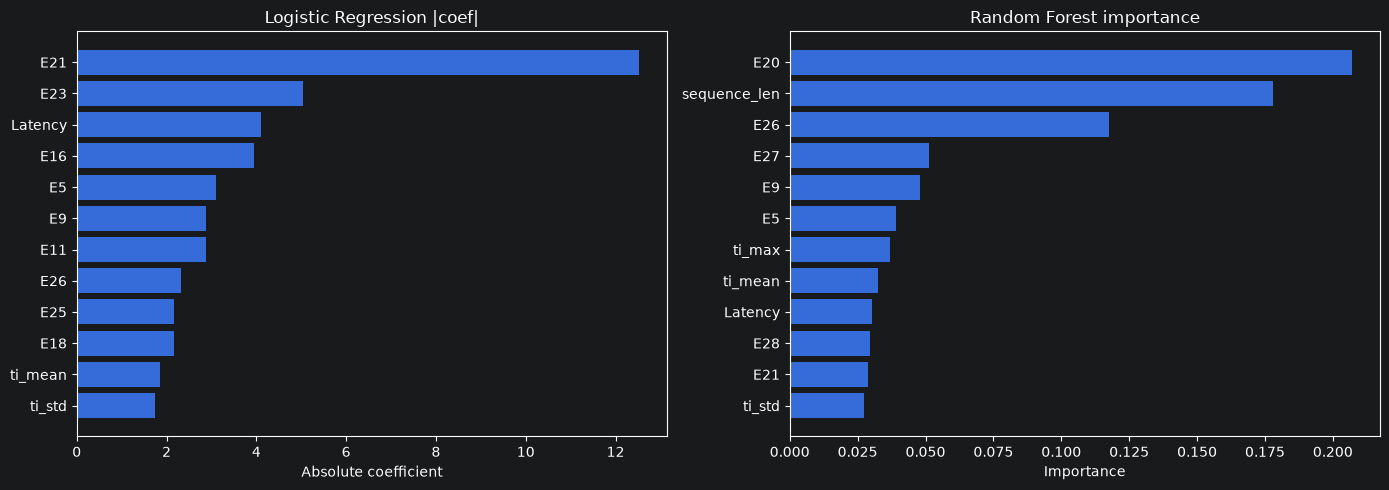

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lr_top = lr_importance.head(12).iloc[::-1]
axes[0].barh(lr_top["feature"], lr_top["abs_coef"])
axes[0].set_title("Logistic Regression |coef|")
axes[0].set_xlabel("Absolute coefficient")

rf_top = rf_importance.head(12).iloc[::-1]
axes[1].barh(rf_top["feature"], rf_top["importance"])
axes[1].set_title("Random Forest importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(FIG_DIR / "tabular_feature_importance.png", dpi=300)
plt.show()

**Промежуточный вывод.** Важные признаки в обеих supervised-моделях связаны с событиями и агрегатами полного блока: `E20`, `E21`, `E23`, `E26`, `sequence_len`, `Latency`, `ti_mean`/`ti_max`. Это подтверждает, что табличный baseline активно использует глобальную структуру завершенного `block_id`, а не online-поведение последовательности.

## 7 Выводы

1. **Табличные supervised baseline дают очень высокое качество.** Logistic Regression и Random Forest хорошо отделяют аномальные блоки по агрегированным признакам всего `block_id`. Это подтверждает, что в данных есть сильный сигнал.

2. **Isolation Forest заметно слабее.** Даже при threshold, выбранном по максимуму F1, модель дает существенно худший F1, много false positives и много false negatives. Это согласуется с идеей, что редкость события или комбинации событий не равна аномалии.

3. **Дальше основной акцент стоит делать на sequence models.** Табличные модели доказывают наличие сигнала, но production-like inference должен учитывать порядок событий и работать с постепенно приходящей последовательностью, а не с полным блоком целиком.